## <center><b> A/B-тестирование </b></center>

На сайте проходит тестирование рекомендательного алгоритма новостной ленты. В эксперименте <b>exp_group = 0</b> - контрольная - <b>группа А</b>, а <b>exp_group = 3</b> - тестовая - <b>группа B</b>. Необходимо определить, увеличило ли внедрение нового алгоритма <b>CTR</b> пользователей по новостной ленте. Положим уровень значимости <b>$\alpha$ = 0.05</b>

<center><div style="font-size: 18px;">$\displaystyle H_0: CTR_B = CTR_A$</div></center>
<center><div style="font-size: 18px;">$\displaystyle H_1: CTR_B > CTR_A$</div></center>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/ab_test.csv')

In [3]:
df.head(3)

,exp_group,user_id,likes,views,ctr
0,3,129833,19,151,0.125828
1,3,27451,4,14,0.285714
2,0,121191,8,65,0.123077


In [4]:
df.isnull().sum()

exp_group    0
user_id      0
likes        0
views        0
ctr          0
dtype: int64

In [5]:
df.groupby(by='exp_group')['likes'].agg(func='count')

exp_group
0     9999
3    10049
Name: likes, dtype: int64

In [6]:
df['group'] = df['exp_group'].apply(func=lambda x: 'control' if x == 0 else 'test')

In [7]:
first_mean  = df.loc[df['exp_group'] == 0, 'ctr'].mean()
second_mean = df.loc[df['exp_group'] == 3, 'ctr'].mean()

In [8]:
print(f'Control CTR mean = {first_mean:.4f}\nTest CTR mean = {second_mean:.4f}')

Control CTR mean = 0.2159
Test CTR mean = 0.2326


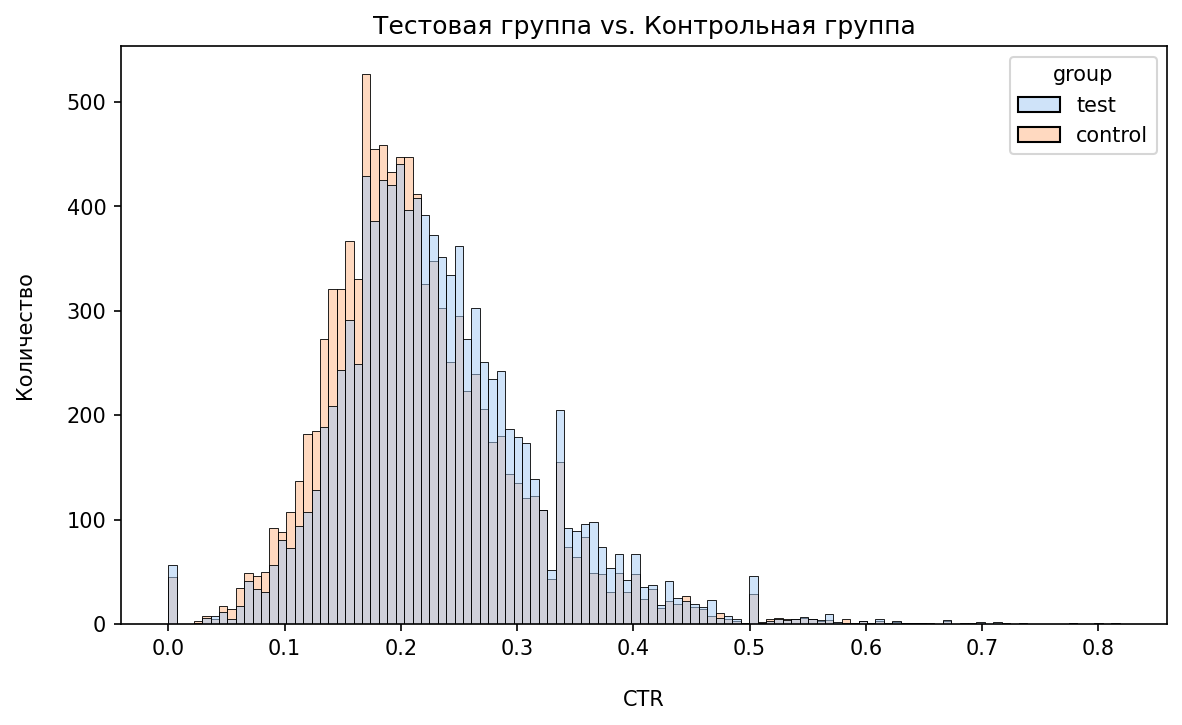

In [9]:
plt.figure(figsize=(9, 5), dpi=150)
sns.histplot(data=df, x='ctr', hue='group', palette='pastel')
plt.title('Тестовая группа vs. Контрольная группа')
plt.xlabel('\nCTR')
plt.ylabel('Количество\n')
plt.show()

Можно предположить, что рассматриваемые группы действительно имеют некоторые различия: <b>группа B</b> смещена вправо относительно <b>группы А</b>. Для построения каких-либо выводов необходимо применить статистический критерий. Распределения имеют схожую форму, в достаточной степени центрированы и не имеют выраженных вероятно выбросов, поэтому для прикидки можно воспользоваться <b>T-тестом Стьюдента</b>.

### <b>1. Классический подход</b>

In [10]:
from pingouin import homoscedasticity

In [11]:
homo_test = homoscedasticity(data=df, dv='ctr', group='group')

In [12]:
homo_test.squeeze()

W            10.953081
pval          0.000936
equal_var        False
Name: levene, dtype: object

In [13]:
from pingouin import ttest, mwu

In [14]:
first_sample  = df[df['exp_group'] == 0] 
second_sample = df[df['exp_group'] == 3]

In [15]:
t_test = ttest(x=first_sample['ctr'].values, y=second_sample['ctr'], alternative='less').round(3)

In [16]:
t_test.squeeze()

T                    -13.897
dof                20032.624
alternative             less
p-val                    0.0
CI95%          [-inf, -0.01]
cohen-d                0.196
BF10               1.617e+40
power                    1.0
Name: T-test, dtype: object

Для большей надежности также воспользуемся <b>U-тестом Манна-Уитни</b>.

In [17]:
mwu_test = mwu(x=first_sample['ctr'].values, y=second_sample['ctr'], alternative='less').round(3)

In [18]:
mwu_test.squeeze()

U-val          43682792.0
alternative          less
p-val                 0.0
RBC                -0.131
CLES                0.565
Name: MWU, dtype: object

Так, <b>T-тест Стьюдента</b> и <b>U-тест Манна-Уитни</b> показывают p-value, значительно меньший установленного уровня значимости <b>$\alpha$</b>. Значит, наблюдаемая разница в <b>CTR</b> между <b>группой А</b> и <b>группой B</b> является статистически значимой, и тестируемый рекомендательный алгоритм действительно положительно влияет на <b>CTR</b>.

### <b>2. Сглаживание CTR</b>

Анализируя имеющиеся данные, можно заметить, что в них присутствует достаточное количество пользователей с малым числом просмотров. Оценка <b>CTR</b> конкретного пользователя в случае малого числа просмотров может быть как неоправданно завышена, так и занижена. Такие выбросы могут ломать выборочные значения статистик критериев.

Проблема в том, что <b>CTR пользователя</b> с 1 просмотром и 1 кликом (<b>CTR=1</b>) статистически ненадёжен, но при этом имеет такой же вес в расчёте среднего, как и <b>CTR</b> пользователя с 1000 просмотров. Это искажает распределение и снижает мощность статистических тестов.

Для решение этой проблемы используется сглаживание, которое подтягивает экстремальные оценки отдельных пользователей к усредненному <b>CTR</b> по выборке:

<center><div style="font-size: 18px;">$\displaystyle sCTR_u = \frac{clicks_u + \alpha * gCTR}{views_u + \alpha}$</div></center><br>


где $\alpha$ - гиперпараметр сглаживания, $sCTR_u$ - сглаженный CTR пользователя, $gCTR$ - CTR для контрольной/тестовой группы, $clicks_u$ - клики пользователя, $views_u$ - просмотры пользователя

In [32]:
def get_smoothed_ctr(likes_u: int, views_u: int, g_ctr: float, alpha: float) -> float:
    s_ctr = (likes_u + alpha * g_ctr) / (views_u + alpha)
    return s_ctr

In [33]:
test_ctr    = df.loc[df['group'] == 'test', 'likes'].sum() / df.loc[df['group'] == 'test', 'views'].sum()
control_ctr = df.loc[df['group'] == 'control', 'likes'].sum() / df.loc[df['group'] == 'control', 'views'].sum()

In [34]:
print(f'Test CTR: {test_ctr:.4f}\nControl CTR: {control_ctr:.4f}')

Test CTR: 0.2243
Control CTR: 0.2082


In [35]:
first_sample_smoothed = df[df['group'] == 'control'].copy()
first_sample_smoothed['s_ctr'] = first_sample_smoothed.apply(func=lambda x: get_smoothed_ctr(x['likes'], x['views'], control_ctr, 5), axis=1)

In [36]:
second_sample_smoothed = df[df['group'] == 'test'].copy()
second_sample_smoothed['s_ctr'] = second_sample_smoothed.apply(func=lambda x: get_smoothed_ctr(x['likes'], x['views'], test_ctr, 5), axis=1)

In [37]:
first_mean_smoothed  = first_sample_smoothed.loc[first_sample_smoothed['group'] == 'control', 's_ctr'].mean()
second_mean_smoothed = second_sample_smoothed.loc[second_sample_smoothed['group'] == 'test', 's_ctr'].mean()

In [38]:
print(f'Control smoothed CTR mean = {first_mean_smoothed:.4f}\nTest smoothed CTR mean = {second_mean_smoothed:.4f}')

Control smoothed CTR mean = 0.2143
Test smoothed CTR mean = 0.2309


In [39]:
smoothed_df = pd.concat([first_sample_smoothed, second_sample_smoothed])

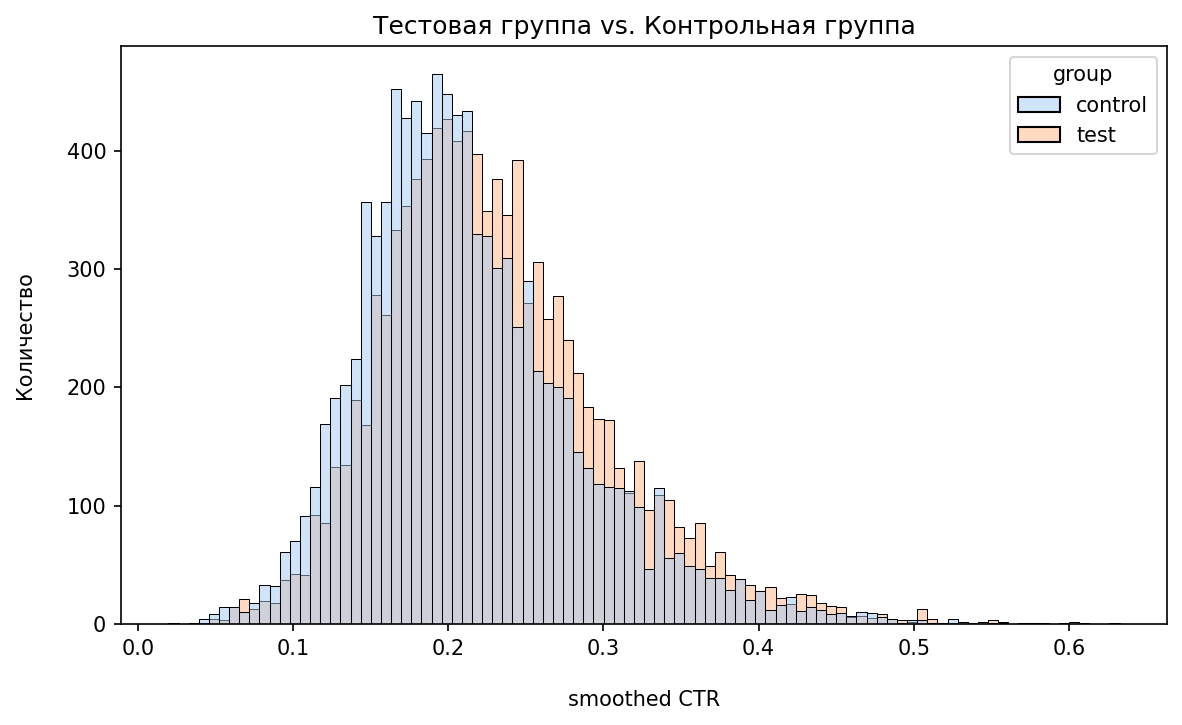

In [40]:
plt.figure(figsize=(9, 5), dpi=150)
sns.histplot(data=smoothed_df, x='s_ctr', hue='group', palette='pastel')
plt.title('Тестовая группа vs. Контрольная группа')
plt.xlabel('\nsmoothed CTR')
plt.ylabel('Количество\n')
plt.show()

Видно, что выбросы <b>CTR</b> как в <b>группе А</b>, так и в <b>группе B</b> сгладились, а значит, дисперсия статистики критерия стала меньше. Далее используем <b>T-критерием Стьюдента</b> и <b>U-критерием Манна-Уитни</b> над нашими сглаженными данными и сделаем выводы. 

In [41]:
smoothed_t_test = ttest(x=first_sample_smoothed['s_ctr'], y=second_sample_smoothed['s_ctr'], alternative='less').round(3)

In [42]:
smoothed_t_test.squeeze()

T                    -16.341
dof                20038.801
alternative             less
p-val                    0.0
CI95%          [-inf, -0.01]
cohen-d                0.231
BF10               1.153e+56
power                    1.0
Name: T-test, dtype: object

In [43]:
smoothed_mwu = mwu(x=first_sample_smoothed['s_ctr'], y=second_sample_smoothed['s_ctr'], alternative='less').round(3)

In [44]:
smoothed_mwu.squeeze()

U-val          42897043.0
alternative          less
p-val                 0.0
RBC                -0.146
CLES                0.573
Name: MWU, dtype: object

Таким образом, <b>T-тест Стьюдента</b> и <b>U-тест Манна-Уитни</b> показывают p-value, значительно меньший установленного уровня значимости <b>$\alpha$</b> для сглаженных данных. Значит, наблюдаемая разница в сглаженных <b>CTR</b> между <b>группой А</b> и <b>группой B</b> является статистически значимой, и тестируемый рекомендательный алгоритм действительно положительно влияет на <b>CTR</b>.<br>Важно отметить, что применение <b>T-теста Стьюдента</b> в случае <b>ratio-метрик</b> не является желательным, так как в отдельных случаях, когда нарушаются предположения об групповых распределениях, будет увеличиваться <b>ошибка 1-го рода</b>. Поэтому, чтобы быть уверенным в полученных результатах, воспользуемся другими методиками выявления статистически значимых отклонений.

### <b>3. Пуассоновский bootstrap</b>

Вместо того, чтобы генерировать выборки на основе <b>группы А</b> и <b>группы B</b>, можно генерировать выборки, которые описывали бы, сколько раз конкретный <b>user</b> (а именно его <b>likes</b> и <b>views</b>) войдет в эту сгенерированную выборку. В силу того, что размеры рассматриваемых групп достаточно большие, можно перейти от <b>распределения Бернулли</b> (которое описывает модель взятия/пропуска конкретного user'a в генерируемой выборке) к <b>распределению Пуассона</b> с параметром $\lambda = 1$.

In [45]:
from scipy.stats.distributions import poisson

In [46]:
def poisson_bootstrap(likes: np.array, views: np.array, n_iterations: int) -> float:
    distribution, size = poisson(mu=1), len(likes)
    
    bootstrap  = distribution.rvs((n_iterations, size)).astype(dtype='int16')
    ctr = (likes @ bootstrap.T) / (views @ bootstrap.T)
    return ctr

In [47]:
first_sample.head(3)

,exp_group,user_id,likes,views,ctr,group
2,0,121191,8,65,0.123077,control
3,0,116645,11,48,0.229167,control
4,0,112152,5,24,0.208333,control


In [48]:
second_sample.head(3)

,exp_group,user_id,likes,views,ctr,group
0,3,129833,19,151,0.125828,test
1,3,27451,4,14,0.285714,test
6,3,30709,2,14,0.142857,test


In [54]:
n_iterations = 2000
first_ctr  = poisson_bootstrap(first_sample['likes'].values, first_sample['views'].values, n_iterations)
second_ctr = poisson_bootstrap(second_sample['likes'].values, second_sample['views'].values, n_iterations)

In [55]:
tmp_df1 = pd.DataFrame(data=first_ctr, columns=['ctr'])
tmp_df1['group'] = 'control'

In [56]:
tmp_df2 = pd.DataFrame(data=second_ctr, columns=['ctr'])
tmp_df2['group'] = 'test'

In [57]:
bootstrap_df = pd.concat([tmp_df1, tmp_df2])

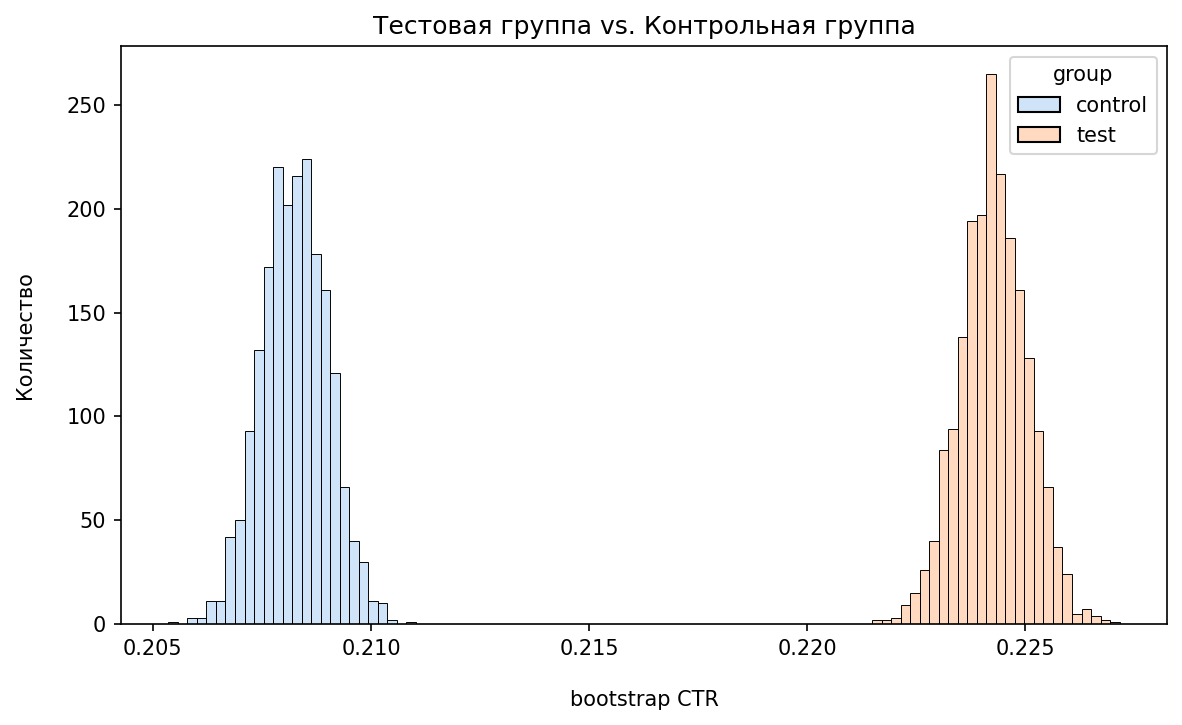

In [58]:
plt.figure(figsize=(9, 5), dpi=150)
sns.histplot(data=bootstrap_df, x='ctr', hue='group', palette='pastel', bins=100)
plt.title('Тестовая группа vs. Контрольная группа')
plt.xlabel('\nbootstrap CTR')
plt.ylabel('Количество\n')
plt.show()

Видно, что полученные с помощью <b>Пуассоновского bootstrap'a</b> распределения для <b>CTR</b> <b>группы А</b> и <b>группы B</b> заметно отличаются, и очевидно, их <b>95% доверительные интервалы</b> пересекаться не будут. Значит, различия в <b>CTR</b> между группами статистически значимы, рекомендательный алгоритм положительно влияет на <b>CTR</b> ленты.

### <b>4. Бакетное преобразование</b>

По своей сути бакетное преобразование очень похоже на <b>bootstrap</b>. Мы также случайным образом выбираем пользователей из нашей группы (в отличие от bootstrap'a выбираем без повторений) и разбиваем их на некоторое количество подгрупп - <b>бакетов</b>. Далее поверх полученных бакетов используем знакомые нам статистические критерии и делаем вывод.

In [59]:
def make_buckets(df: pd.DataFrame, n_buckets: int, likes_col: str = 'likes', views_col: str = 'views') -> pd.Series:
    df['bucket'] = (df[likes_col].astype(str) + '_' + df[views_col].astype(str) + str(np.random.randint(1, 10))).apply(hash) % n_buckets

    bucket_stats = df.groupby('bucket').agg({likes_col: 'sum', views_col: 'sum'})
    bucket_stats['ctr'] = bucket_stats[likes_col] / bucket_stats[views_col]

    result = pd.Series(index=range(n_buckets), dtype=float)
    result[bucket_stats.index] = bucket_stats['ctr']
    result = result.fillna(0)

    return result 

In [60]:
control_copy = first_sample.copy()
test_copy    = second_sample.copy()

In [63]:
control_buckets = make_buckets(control_copy, n_buckets=50)
test_buckets    = make_buckets(test_copy, n_buckets=50)

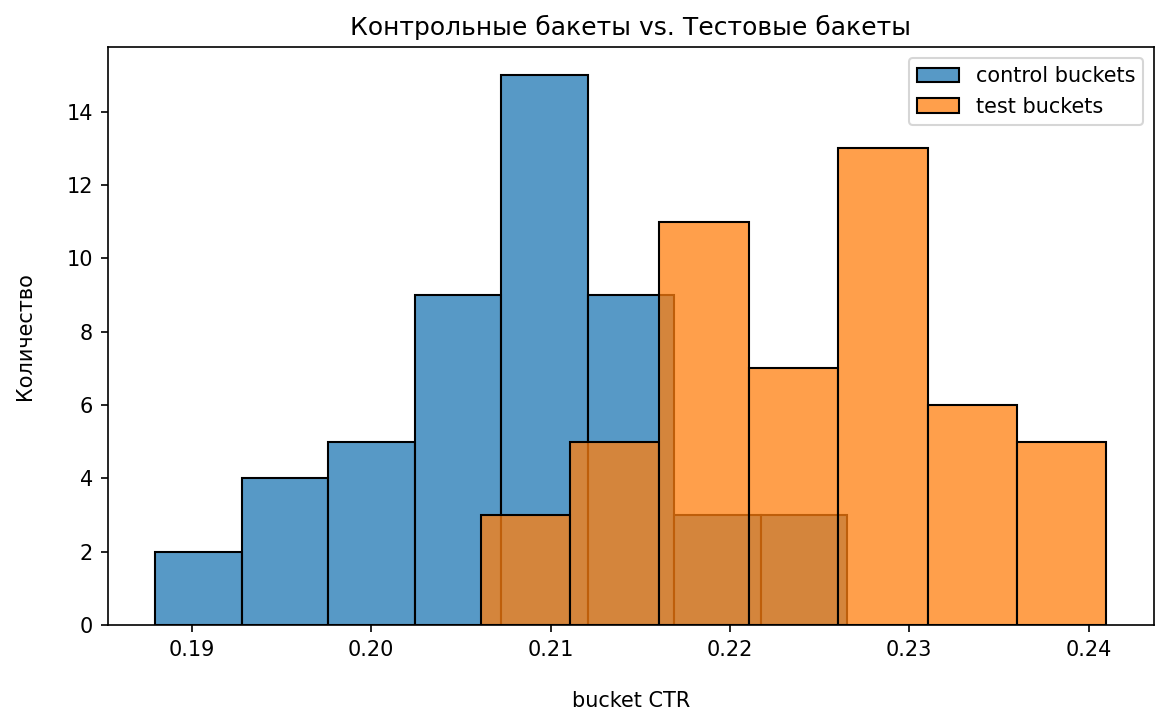

In [64]:
plt.figure(figsize=(9, 5), dpi=150)
sns.histplot(data=control_buckets, label='control buckets')
sns.histplot(data=test_buckets, label='test buckets')
plt.xlabel('\nbucket CTR')
plt.ylabel('Количество\n')
plt.title('Контрольные бакеты vs. Тестовые бакеты')
plt.legend()
plt.show()

Как было сказано ранее, над полученным бакетами можно использовать хорошо знакомые статистические критерии. Воспользуемся U-критерием Манна-Уитни. 

In [65]:
bucket_mwu = mwu(x=control_buckets, y=test_buckets, alternative='less')

In [66]:
bucket_mwu.squeeze()

U-val          225.0
alternative     less
p-val            0.0
RBC            -0.82
CLES            0.91
Name: MWU, dtype: object

Видно, что <b>p-value</b> для <b>U-критерия Манна-Уитни</b> меньше уровня значимости и в целом предельно мал, поэтому наблюдаемая разность в <b>CTR</b> между полученными распределениями бакетов является статистисчески значимой, значит, и разность между оригинальными распределениями <b>CTR</b> в <b>группе А</b> и <b>группе B</b> также является статистически значимой.    

### <b>5. Линеаризация </b>

Вместо того, чтобы сравнивать средние <b>CTR</b> по группам, мы можем переформулировать нашу задачу. Предварительно для <b>группы А</b> рассчитаем групповой <b>CTR</b>: 

<center>
$$CTR_A = \frac{\sum_{i=1}^{n} likes_i}{\sum_{i=1}^{n} views_i}$$
</center>

Далее для каждого пользователя введем линеаризованную псевдо-метрику:


<center>
$$linearized\_likes_i = likes_i - CTR_A * views_i$$
</center>

Эту метрику можно интерпретировать, как "сколько лайков пользователь получил сверх ожидаемого, если бы его просмотры ковертировались со средним $CTR_A$ контрольной группы". Затем полученные значения контрольной и тестовой групп можно сравнить Т-тестом Стьюдента.

In [68]:
print(f'control CTR: {control_ctr:.4f}')

control CTR: 0.2082


In [74]:
linearized_df = df.copy()
linearized_df['linearized_likes'] = linearized_df['likes'] - control_ctr * linearized_df['views']

In [75]:
linearized_df.head(3)

,exp_group,user_id,likes,views,ctr,group,linearized_likes
0,3,129833,19,151,0.125828,test,-12.443655
1,3,27451,4,14,0.285714,test,1.084694
2,0,121191,8,65,0.123077,control,-5.535348


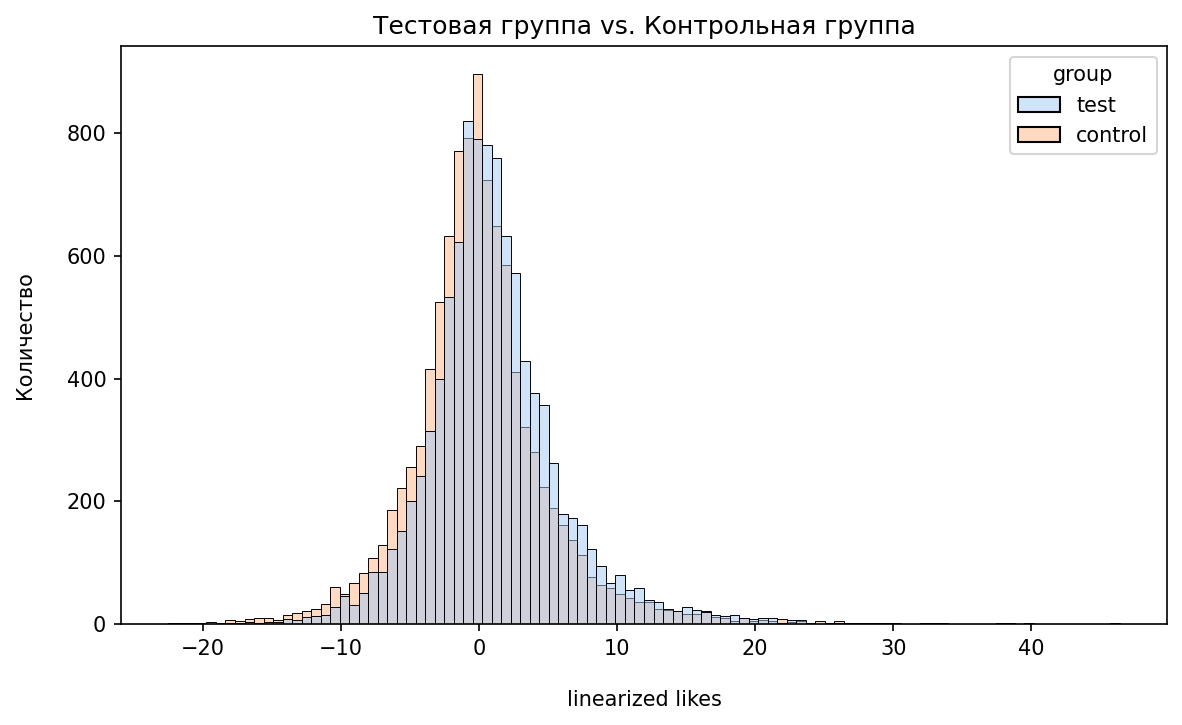

In [76]:
plt.figure(figsize=(9, 5), dpi=150)
sns.histplot(data=linearized_df, x='linearized_likes', hue='group', palette='pastel', bins=100)
plt.title('Тестовая группа vs. Контрольная группа')
plt.xlabel('\nlinearized likes')
plt.ylabel('Количество\n')
plt.show()

In [78]:
linearized_t_test = ttest(x=linearized_df.loc[df['group'] == 'control', 'linearized_likes'].values,
                          y=linearized_df.loc[df['group'] == 'test', 'linearized_likes'].values,
                          alternative='less')

In [79]:
linearized_t_test.squeeze()

T                 -15.214995
dof             20040.497219
alternative             less
p-val                    0.0
CI95%          [-inf, -0.96]
cohen-d             0.214922
BF10               2.807e+48
power                    1.0
Name: T-test, dtype: object

Так, аналогично опробованным ранее подходам, <b>метод линеаризации</b> также выявляет статистически значимые отклонения между <b>группой А</b> и <b>группой B</b>

### <b>Проверка</b>

Как показали проведенные тесты, в <b>CTR</b> действительно наблюдаются статистически значимые различия. Однако важно понимать, что они могли быть достигнуты за счет того, что в тестовой группе могло массово уменьшиться число просмотров (<b>views</b>) на пользователя. Поэтому необходимо дополнительно проверить просмотры в <b>группе А</b> и <b>группе B</b>, чтобы исключить такой исход и быть уверенными в полученных результатах. 

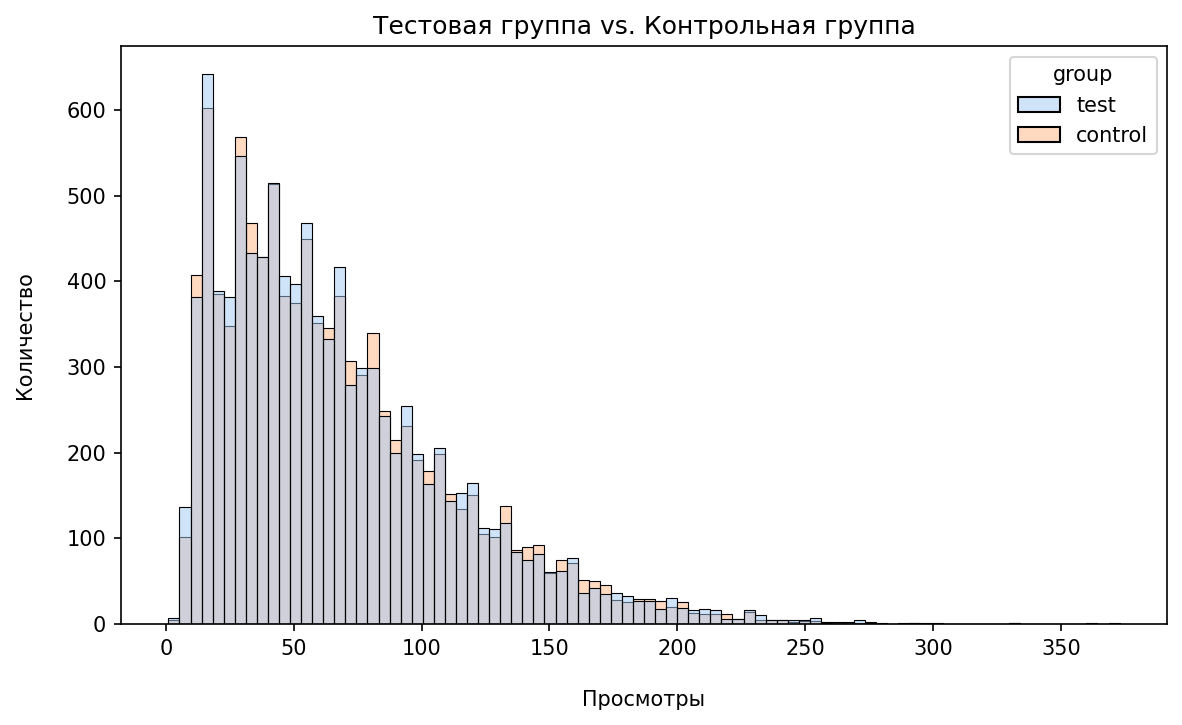

In [55]:
plt.figure(figsize=(9, 5), dpi=150)
sns.histplot(data=df, x='views', hue='group', palette='pastel')
plt.title('Тестовая группа vs. Контрольная группа')
plt.xlabel('\nПросмотры')
plt.ylabel('Количество\n')
plt.show()

Распределения тестовой и контрольной групп достаточно сильно смещены, поэтому в дальнейшем можем использовать только непараметрические критерии. Однако можно попробовать трансформировать их с помощью, например, <b>логарифмического преобразования</b>. Возможно, это исправит ситуацию.

In [66]:
log_df = df.copy()
log_df['log_views'] = np.log(df['views'])

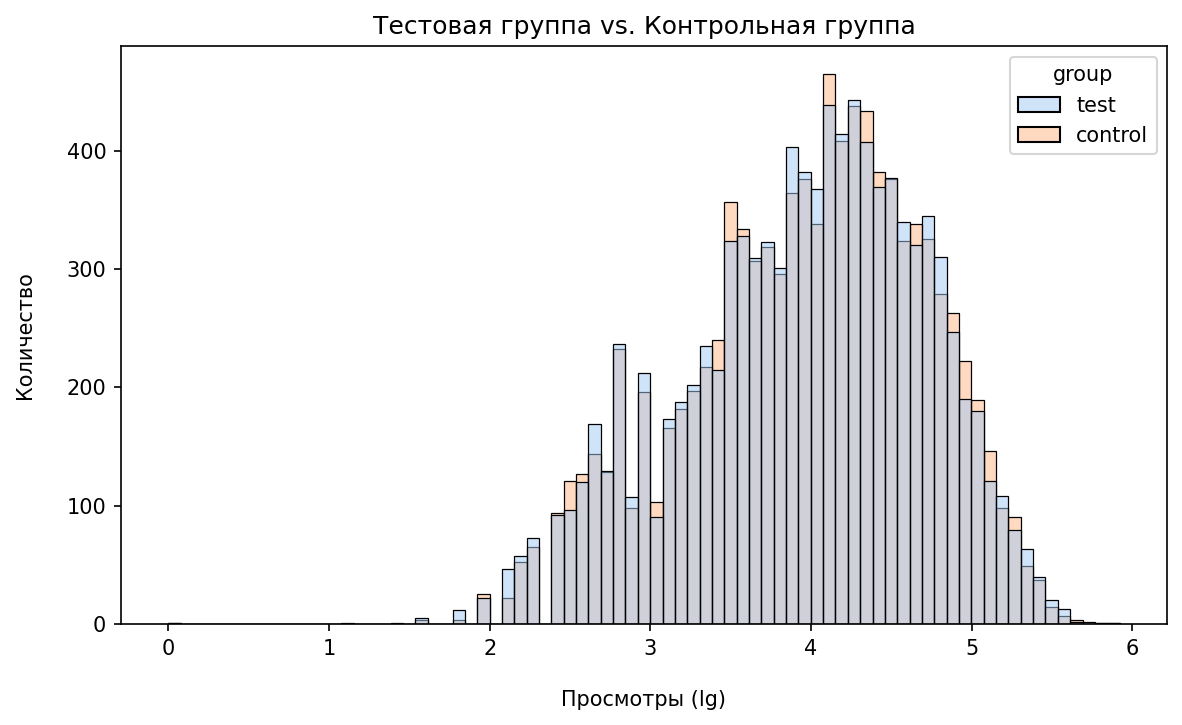

In [67]:
plt.figure(figsize=(9, 5), dpi=150)
sns.histplot(data=log_df, x='log_views', hue='group', palette='pastel')
plt.title('Тестовая группа vs. Контрольная группа')
plt.xlabel('\nПросмотры (lg)')
plt.ylabel('Количество\n')
plt.show()

Теперь распределения больше похожи на нормальные, поэтому с учетом размеров <b>группы А</b> и <b>группы B</b> можно воспользоваться как <b>U-критерием Манна-Уитни</b>, так и <b>T-критерием Стьюдента</b>.

In [71]:
views_t_test = ttest(x=log_df.loc[log_df['group'] == 'control', 'views'].values, 
                     y=log_df.loc[log_df['group'] == 'test', 'views'].values,
                     alternative='less')

In [72]:
views_t_test.squeeze()

T                  0.717143
dof            20045.982928
alternative            less
p-val              0.763353
CI95%          [-inf, 1.52]
cohen-d             0.01013
BF10                  0.041
power              0.009089
Name: T-test, dtype: object

In [73]:
views_mwu = mwu(x=log_df.loc[log_df['group'] == 'control', 'views'].values, 
                y=log_df.loc[log_df['group'] == 'test', 'views'].values,
                alternative='less')

In [74]:
views_mwu.squeeze()

U-val          50640868.5
alternative          less
p-val             0.83608
RBC               0.00798
CLES              0.49601
Name: MWU, dtype: object

Таким образом, новый алгоритм не привел к снижению просмотров, а значит выводы по <b>CTR</b>, полученные раннее, являются верными, и новый рекомендательный алгоритм ленты действительно положительно влияет на <b>CTR</b>.

### <b>Вывод</b>

По результатам эксперимента, проходившего в группах 0 и 3, был получен статистически значимый результат: увеличение <b>CTR</b> в тестовой группе при неизменившемся количестве просмотров относительно контрольной. Рекомендуется раскатать новый алгоритм на всех пользователей.